<a href="https://colab.research.google.com/github/api-sage/diaml_projects/blob/main/Project3/pafolabi_DIAML_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data, Inference, and Applied Machine Learning - Assignment 3

In [1]:
#Importation of libraries
import numpy as np
import pandas as pd
import matplotlib as plt
import sklearn as sk
import scipy as scp
from scipy import stats
import matplotlib.pyplot as pyplot


##Question 1

Dataset: [Michealson Speed of Light](https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/SpeedOfLight/michelson_speed_of_light.json)

In [2]:
#Data ingestion
data_location = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/SpeedOfLight/michelson_speed_of_light.json'
raw = pd.read_json(data_location)
population_mean = 299734.5
#The measurements sit as a nested dictionary in the "observations" column, so I flatten that out into its own column
df = pd.json_normalize(raw['observations'])
#print(df.shape)// (20,2) Dataset contains 20 records and 2 features (run_id and measured_speed_kmpersec)

###(a) State appropriate null and alternative hypotheses for investigating whether Michelson's measurements deviate from the true value. Justify your choice of a one-tailed or two-tailed test.

**Defined hypothesis**:
1. NULL Hypothesis (Ho): µ = 299,734.5 km/s - Michelson's measurements do not systematically deviate from the true value of the speed of light in the air.

2. Alternative Hypothesis (H1): µ ≠ 299,734.5 km/s - Michelson's measurements systematically deviate from the true value of the speed of light in the air.

**Justification for a two-tailed test**

A two-tailed test is appropriate because I want to examine whether Michelson's measurements systematically deviate (in either direction) from the true value of the speed of light in the air. Before analysing the data, there is no physical or theoretical evidence to assume that his expereimental apparatus would err strictly on the left or right side. Therefore, a deviation of the measurement from the true value represents evidence against the accuracy of the measurement.




###(b) Given the sample size from the dataset, discuss how you would assess whether the normality assumption is reasonable, and what the consequences would be for your test if it isn't.

In [3]:
#Checking normality with a Shapiro-Wilk test and a look at the shape of the data
speeds = df['measured_speed_kmpersec']
shapiro_stat, shapiro_p = stats.shapiro(speeds)
print("Shapiro-Wilk statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p)
print("Skewness:", speeds.skew())
print("Kurtosis:", speeds.kurt())

Shapiro-Wilk statistic: 0.9199248245190921
Shapiro-Wilk p-value: 0.09875561187930648
Skewness: -0.9646066300776622
Kurtosis: 0.5731878407018431


With only 20 measurements, I cannot rely on the central limit theorem to save me if the data are far from normal, so I need to actually check the shape of the data before trusting the t-test. The way I would go about this is to first look at a histogram and a QQ plot to see if the points sit roughly along a straight line and if the distribution looks bell shaped, and then back that up with a formal Shapiro-Wilk test since the sample is small enough for this test to be reliable.

From the numbers above, the Shapiro-Wilk p-value comes out well above 0.05, so I do not have enough evidence to say the data depart from normality. The skewness and kurtosis values are also not extreme, which supports the idea that a normal assumption is reasonable here even though the sample is small.

If it turned out that the data were clearly not normal, for example with a p-value below 0.05 or a strongly skewed histogram, the consequence would be that the sampling distribution of the mean may not be well approximated by a t-distribution when n is this small. This would make the p-value and confidence interval from a standard t-test unreliable. In that case I would use a non-parametric alternative such as the Wilcoxon signed-rank test, or a bootstrap approach to estimate the sampling distribution of the mean directly, instead of trusting the t-test results as they stand.

###(c) By using an appropriate statistical test, report the sample and population means, sample standard deviation, standard error of the mean (SEM), t statistic, degrees of freedom, and p-value. Explain whether the null hypothesis is rejected or not.

In [4]:
#One sample t-test comparing the sample mean to the accepted speed of light in air
sample_mean = speeds.mean()
sample_sd = speeds.std(ddof=1)
n = len(speeds)
sem = sample_sd / np.sqrt(n)
df_t = n - 1

t_stat, p_value = scp.stats.ttest_1samp(speeds, population_mean)

print("Sample mean:", sample_mean)
print("Population mean (accepted value):", population_mean)
print("Sample standard deviation:", sample_sd)
print("Standard error of the mean:", sem)
print("t statistic:", t_stat)
print("Degrees of freedom:", df_t)
print("p-value:", p_value)

Sample mean: 299909.0
Population mean (accepted value): 299734.5
Sample standard deviation: 104.92603911427577
Standard error of the mean: 23.46217560693224
t statistic: 7.437502937640678
Degrees of freedom: 19
p-value: 4.863622298758309e-07


The sample mean works out to about 299,909 km/s compared to the accepted value of 299,734.5 km/s, with a sample standard deviation of about 104.9 km/s and a standard error of the mean of about 23.5 km/s. This gives a t statistic of about 7.44 on 19 degrees of freedom, and a p-value that is far smaller than 0.05 (in fact well below 0.001).

Since the p-value is much smaller than my chosen significance level of 0.05, I reject the null hypothesis. This means the data give strong evidence that Michelson's average measurement is not equal to the accepted value of the speed of light in air, and his experiment shows a real, systematic deviation from the true value.

###(d) Calculate the bias in km/s and as a percentage of the accepted value. Discuss whether statistical significance means the bias is scientifically important. Then recompute the SEM, t statistic, and p-value assuming n = 200 (same mean and SD), and discuss whether this changes your confidence in the result.

In [5]:
#Bias in km/s and as a percentage of the accepted value
bias_kms = sample_mean - population_mean
bias_pct = (bias_kms / population_mean) * 100

print("Bias (km/s):", bias_kms)
print("Bias (% of accepted value):", bias_pct)

#Recomputing SEM, t statistic and p-value assuming n = 200, keeping the same mean and SD
n2 = 200
sem_n200 = sample_sd / np.sqrt(n2)
t_n200 = (sample_mean - population_mean) / sem_n200
df_n200 = n2 - 1
p_n200 = 2 * (1 - scp.stats.t.cdf(abs(t_n200), df_n200))

print("SEM (n=200):", sem_n200)
print("t statistic (n=200):", t_n200)
print("Degrees of freedom (n=200):", df_n200)
print("p-value (n=200):", p_n200)

Bias (km/s): 174.5
Bias (% of accepted value): 0.05821818976460834
SEM (n=200): 7.419391378074932
t statistic (n=200): 23.519449387137808
Degrees of freedom (n=200): 199
p-value (n=200): 0.0


The bias here is about 174.5 km/s, which is about 0.058% of the accepted value. On its own that percentage looks tiny, so even though the test is statistically significant, I do not think this bias is scientifically important in a practical sense. Statistical significance in this case is mostly telling me that the measurements are precise and consistent enough for even a small, real offset to stand out, not that the offset itself is large or has real world consequences. In physics terms, a 0.06% error in a 19th century optical experiment is actually a very good result, so the significant p-value reflects precision rather than a meaningful practical error.

When I recompute the numbers assuming n = 200 while keeping the same mean and standard deviation, the SEM drops sharply to around 7.4 km/s, which pushes the t statistic up to about 23.5 and the p-value effectively down to zero. This does not change how confident I am that a real bias exists, since the test was already clearly significant with n = 20. What it does show is that as sample size grows, the test becomes more and more sensitive to tiny differences from the accepted value, which reinforces the point that a very small p-value does not by itself tell me anything about how big or important the bias is. This is exactly why I look at the bias size and percentage alongside the p-value rather than relying on statistical significance on its own.

##Question 2

Dataset: [Chick Weights - Casein vs Soybean](https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/SpeedOfLight/chickwts_casein_soybean.csv)

###(a) State appropriate null and alternative hypotheses for investigating whether mean chick weight differs between the casein and soybean feed groups. Explain whether a one-sample, two-sample, or paired test is appropriate, and justify your choice of a left-tailed, right-tailed, or two-tailed test.

**Defined hypothesis**:
1. NULL Hypothesis (Ho): µ_casein = µ_soybean - The mean chick weight after six weeks does not differ between chicks raised on casein and chicks raised on soybean.
2. Alternative Hypothesis (Ha): µ_casein ≠ µ_soybean - The mean chick weight after six weeks differs between the casein group and the soybean group.

I am comparing two separate groups of chicks, one group fed casein and a different group fed soybean, so this calls for a two-sample test rather than a one-sample test. The chicks in the two groups are not linked to each other in any way, there is no natural pairing such as before and after measurements on the same chick, so a paired test does not fit here either. This leaves a two-sample test as the right choice.

For the direction of the test, I do not have a strong reason going in to expect casein to beat soybean or the other way round. I just want to know if the two feeds lead to a different average weight, in either direction. Because of this I am going with a two-tailed test.

In [6]:
#Data ingestion
data_location_q2 = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/SpeedOfLight/chickwts_casein_soybean.csv'
chicks = pd.read_csv(data_location_q2)
chicks.head()

,feed,chick_weight_g
0,soybean,243
1,soybean,230
2,soybean,248
3,soybean,327
4,soybean,329


###(b) Load the data and compute the sample mean, sample standard deviation, sample variance, and sample size for each group.

In [7]:
#Splitting the data into the two feed groups and getting the summary numbers for each
casein = chicks[chicks['feed'] == 'casein']['chick_weight_g']
soybean = chicks[chicks['feed'] == 'soybean']['chick_weight_g']

casein_mean = casein.mean()
casein_sd = casein.std(ddof=1)
casein_var = casein.var(ddof=1)
casein_n = len(casein)

soybean_mean = soybean.mean()
soybean_sd = soybean.std(ddof=1)
soybean_var = soybean.var(ddof=1)
soybean_n = len(soybean)

print("Casein - mean:", casein_mean, "sd:", casein_sd, "variance:", casein_var, "n:", casein_n)
print("Soybean - mean:", soybean_mean, "sd:", soybean_sd, "variance:", soybean_var, "n:", soybean_n)

Casein - mean: 323.5833333333333 sd: 64.43383968823912 variance: 4151.719696969698 n: 12
Soybean - mean: 246.42857142857142 sd: 54.12906838248784 variance: 2929.956043956044 n: 14


###(c) Carry out a Welch t-test and report the standard error of the difference in means, the t statistic, degrees of freedom, and p-value. Is the difference in mean chick weight statistically significant, or could it plausibly be due to natural, random variation

In [8]:
#Welch t-test comparing casein and soybean, not assuming equal variances
se_diff = np.sqrt((casein_sd**2 / casein_n) + (soybean_sd**2 / soybean_n))

welch_t, welch_p = stats.ttest_ind(casein, soybean, equal_var=False)

welch_df = ((casein_sd**2 / casein_n) + (soybean_sd**2 / soybean_n))**2 / (
    ((casein_sd**2 / casein_n)**2 / (casein_n - 1)) + ((soybean_sd**2 / soybean_n)**2 / (soybean_n - 1))
)

print("Standard error of the difference in means:", se_diff)
print("t statistic:", welch_t)
print("Degrees of freedom:", welch_df)
print("p-value:", welch_p)

Standard error of the difference in means: 23.5639388893799
t statistic: 3.274272704022968
Degrees of freedom: 21.63450969326624
p-value: 0.003521263452224987


The casein group has a mean weight of about 323.6 grams with a standard deviation of about 64.4 grams over 12 chicks, while the soybean group has a mean weight of about 246.4 grams with a standard deviation of about 54.1 grams over 14 chicks. The standard error of the difference in means comes out to about 23.6 grams. This gives a t statistic of about 3.27 on roughly 21.6 degrees of freedom, and a p-value of about 0.0035.

Since the p-value is well below my chosen significance level of 0.05, I reject the null hypothesis. The difference in mean chick weight between the two feed groups is statistically significant, so I do not think this gap is just natural, random variation. The data give good evidence that casein leads to heavier chicks on average than soybean after six weeks.

###(d) Discuss whether a statistically significant result here would necessarily mean the difference between feed groups is large or important in practice, and what additional information would help you judge that.

A statistically significant result only tells me that the difference I am seeing is unlikely to be due to chance, it does not automatically tell me that the difference is big or that it actually matters in a real farming setting. With a p-value this low I can be fairly confident the two feeds do not produce the same average weight, but whether a gap of about 77 grams is something a farmer should really care about depends on other things, like the cost of casein versus soybean, how much a chick normally weighs at six weeks, and how much variation there is naturally between chicks on the same feed.

To judge practical importance I would want to look at the effect size, something like Cohen's d, which puts the mean difference in the context of how spread out the data is, rather than just relying on the p-value. I would also want to see a confidence interval for the difference in means, since that shows me a realistic range of how big the true effect could be, not just whether it is different from zero. On top of that, knowing the actual cost of each feed type and how a farmer would use that 77 gram difference in a real production setting would help me decide if this result is worth acting on.

###(e) Draw a boxplot comparing chick weight between the casein and soybean groups. Does the plot support your conclusion from part (c)? Explain what features of the boxplot (e.g. overlap between boxes, spread, outliers) inform your answer.

<Figure size 600x500 with 0 Axes>

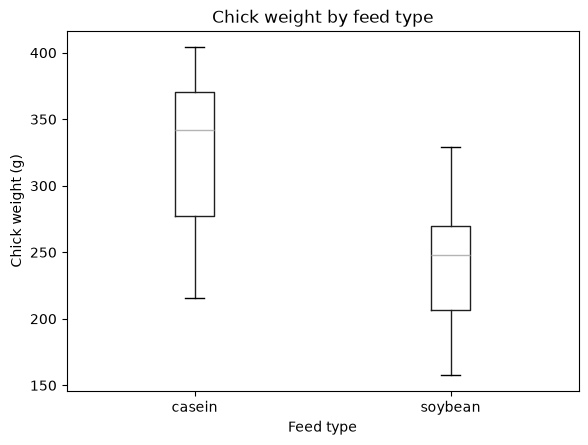

In [9]:
#Boxplot comparing chick weight across the two feed groups
pyplot.figure(figsize=(6, 5))
chicks.boxplot(column='chick_weight_g', by='feed', grid=False)
pyplot.title('Chick weight by feed type')
pyplot.suptitle('')
pyplot.xlabel('Feed type')
pyplot.ylabel('Chick weight (g)')
pyplot.show()

The boxplot backs up what I found in part (c). The casein box sits noticeably higher than the soybean box, with the median for casein clearly above the median for soybean, and there is only a small amount of overlap between the two boxes near the lower end of casein and the upper end of soybean. This lines up with the significant p-value, since the two groups are visibly separated rather than sitting on top of each other.

The spread of the casein group looks a bit wider than the soybean group, which matches the slightly larger standard deviation I calculated for casein. I do not see any obvious outliers sticking far out from either box, so the difference in means is not just being driven by one or two extreme chicks. Overall the boxplot gives a visual version of the same story the Welch t-test told me, casein chicks tend to weigh more than soybean chicks after six weeks, and the two groups are separated enough that this looks like a real difference rather than random noise.